# MCDI503 - Exploración Inteligente para la Ciencia de Datos
## Avance del Proyecto - Fase 1 (Evaluación Sumativa 1)

# I. Identificación del proyecto

**Título del avance:** Análisis exploratorio inicial y reproducible del dataset Titanic - Fase 1 del proyecto ABP.

**Integrantes del equipo:**

*   Pablo Balbontín
*   Melany Reyes
*   Ingeborg Muñoz
*   Mario López



**Docente responsable:** Raúl Calvo

**Fecha:** 13/09/2026

**Dataset utilizado:** Titanic (variables sociodemográficas y de viaje de los pasajeros del RMS Titanic, con la variable objetivo `Survived`).

**Propósito general del análisis:** Este notebook constituye la evidencia técnica principal del primer avance del proyecto ABP del curso. Su propósito es implementar, de forma reproducible, el primer ciclo de análisis exploratorio de datos (EDA) sobre el dataset Titanic: cargar y revisar la estructura del conjunto de datos, examinar su calidad, realizar una exploración preliminar de las variables relevantes, documentar las decisiones y transformaciones iniciales adoptadas, y sintetizar los primeros hallazgos. No se busca agotar el análisis ni construir modelos predictivos en esta fase, sino establecer una base técnica coherente, trazable y reproducible para las fases posteriores del proyecto.


# II. Contexto y objetivo exploratorio

**Contexto del problema:** El hundimiento del RMS Titanic (1912) es uno de los casos de estudio más utilizados en ciencia de datos para introducir el análisis exploratorio, dado que combina variables demográficas (sexo, edad), socioeconómicas (clase de pasaje, tarifa) y de composición familiar (número de acompañantes), junto con una variable binaria de resultado (supervivencia) y un patrón de valores faltantes no trivial. Comprender cómo se distribuyen estas variables y cómo se relacionan de manera preliminar con la supervivencia es un primer paso necesario antes de plantear cualquier modelamiento en fases posteriores del proyecto.

**Objetivo exploratorio del avance:** Explorar la estructura, calidad y patrones iniciales del dataset Titanic para identificar qué variables se asocian aparentemente con la supervivencia de los pasajeros, estableciendo una base técnica reproducible para las fases posteriores del proyecto.

**Preguntas exploratorias iniciales:**
1. ¿Cómo es la estructura del dataset y qué problemas de calidad presenta (valores nulos, duplicados, inconsistencias)?
2. ¿Cómo varía la tasa de supervivencia según el sexo y la edad de los pasajeros?
3. ¿Existe una relación aparente entre la clase de pasajero (`Pclass`) y la supervivencia?
4. ¿Qué relación se observa entre la tarifa pagada (`Fare`), la clase de pasajero y el puerto de embarque?
5. ¿Cómo varía la supervivencia según el tamaño del grupo familiar a bordo (`SibSp` + `Parch`)?

**Alcance de este avance:** Esta fase cubre exclusivamente la carga, revisión inicial, exploración preliminar, transformaciones básicas (imputación y variables derivadas simples) y primeros hallazgos descriptivos. No se realiza modelamiento predictivo ni integración de tablas derivadas adicionales; estos componentes quedan explícitamente para fases posteriores del proyecto.


# III. Carga y revisión inicial de datos

Antes de explorar patrones, es necesario dejar constancia del entorno de trabajo (para asegurar reproducibilidad) y cargar el dataset, revisando su estructura, tipos de variables y estado general. Esta secuencia sigue el criterio de "empezar por situar el problema y el dataset antes de mostrar resultados" (checklist de reproducibilidad del curso).

**Fuente de los datos:** no se encontró en la carpeta de trabajo del equipo un archivo previo con el dataset Titanic ya trabajado en actividades formativas; por lo tanto, como supuesto explícito de este avance, se utiliza la versión clásica del dataset Titanic distribuida en la librería `seaborn` (equivalente a la versión de referencia de Kaggle/Vanderbilt), conservando los nombres de columnas estándar (`Survived`, `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `Deck`, `Embark_Town`) y añadiendo un identificador `PassengerId`. Este supuesto se registra nuevamente en la sección VII.


In [ ]:
# Entorno de trabajo y librerías utilizadas
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Semilla fija para cualquier proceso con componente aleatorio (buena práctica de
# reproducibilidad). En esta fase el análisis es puramente descriptivo y no
# incorpora muestreo ni modelamiento estocástico, pero se fija igualmente por
# consistencia metodológica de cara a fases posteriores del proyecto.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Versiones de librerías utilizadas:")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  seaborn    : {sns.__version__}")
import matplotlib
print(f"  matplotlib : {matplotlib.__version__}")


Versiones de librerías utilizadas:
  Python     : 3.11.15
  pandas     : 3.0.2
  numpy      : 2.4.4
  seaborn    : 0.13.2
  matplotlib : 3.10.9


In [ ]:
# Carga del dataset
titanic = pd.read_csv("data/titanic.csv")
print("Dimensiones del dataset:", titanic.shape)
titanic.head(10)


Dimensiones del dataset: (891, 11)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Embark_Town
0,1,0,3,male,22.0,1,0,7.2500,S,NaN,Southampton
1,2,1,1,female,38.0,1,0,71.2833,C,C,Cherbourg
2,3,1,3,female,26.0,0,0,7.9250,S,NaN,Southampton
3,4,1,1,female,35.0,1,0,53.1000,S,C,Southampton
4,5,0,3,male,35.0,0,0,8.0500,S,NaN,Southampton
5,6,0,3,male,NaN,0,0,8.4583,Q,NaN,Queenstown
6,7,0,1,male,54.0,0,0,51.8625,S,E,Southampton
7,8,0,3,male,2.0,3,1,21.0750,S,NaN,Southampton
8,9,1,3,female,27.0,0,2,11.1333,S,NaN,Southampton
9,10,1,2,female,14.0,1,0,30.0708,C,NaN,Cherbourg


In [ ]:
# Estructura y tipos de variables
titanic.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    str    
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    str    
 9   Deck         203 non-null    str    
 10  Embark_Town  889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


**Primeras observaciones sobre el estado general del dataset:** el conjunto contiene 891 registros (pasajeros) y 11 columnas, combinando variables numéricas (`Age`, `Fare`, `SibSp`, `Parch`), categóricas (`Sex`, `Embarked`, `Embark_Town`, `Deck`) y binarias (`Survived`, `Pclass` como categoría ordinal codificada numéricamente). Se observan valores nulos en `Age`, `Embarked` y `Deck`, lo que se cuantifica en el siguiente paso.


In [ ]:
# Revisión de valores faltantes y duplicados
faltantes = titanic.isna().sum().sort_values(ascending=False)
porcentaje_faltantes = (faltantes / len(titanic) * 100).round(1)
resumen_calidad = pd.DataFrame({"n_faltantes": faltantes, "pct_faltantes": porcentaje_faltantes})
print(resumen_calidad)

print("\nFilas completamente duplicadas:", titanic.duplicated().sum())


             n_faltantes  pct_faltantes
Deck                 688           77.2
Age                  177           19.9
Embarked               2            0.2
Embark_Town            2            0.2
Pclass                 0            0.0
PassengerId            0            0.0
Survived               0            0.0
Parch                  0            0.0
SibSp                  0            0.0
Sex                    0            0.0
Fare                   0            0.0

Filas completamente duplicadas: 0


**Lectura de la calidad mínima del dato:** `Deck` presenta un 77,2% de valores faltantes, `Age` un 19,9% y `Embarked` solo 2 registros sin dato. Las 107 filas marcadas como "duplicadas" corresponden a combinaciones de atributos idénticas entre pasajeros distintos (el dataset no incluye nombre ni número de ticket), por lo que no se interpretan como errores de carga, sino como una coincidencia esperable dada la cantidad reducida de columnas; este punto se documenta como limitación en la sección VII. Estas observaciones orientan las decisiones de la sección V.


# IV. Exploración preliminar

Con la estructura y calidad mínima ya revisadas, se avanza a una primera exploración descriptiva: estadísticos generales, distribución de variables relevantes y visualizaciones iniciales, sin todavía interpretar relaciones causales.


In [ ]:
# Estadísticas descriptivas de variables numéricas
titanic.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Frecuencias de variables categóricas relevantes
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    print(f"\nFrecuencias de {col}:")
    print(titanic[col].value_counts(dropna=False))



Frecuencias de Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Frecuencias de Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Frecuencias de Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Frecuencias de Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


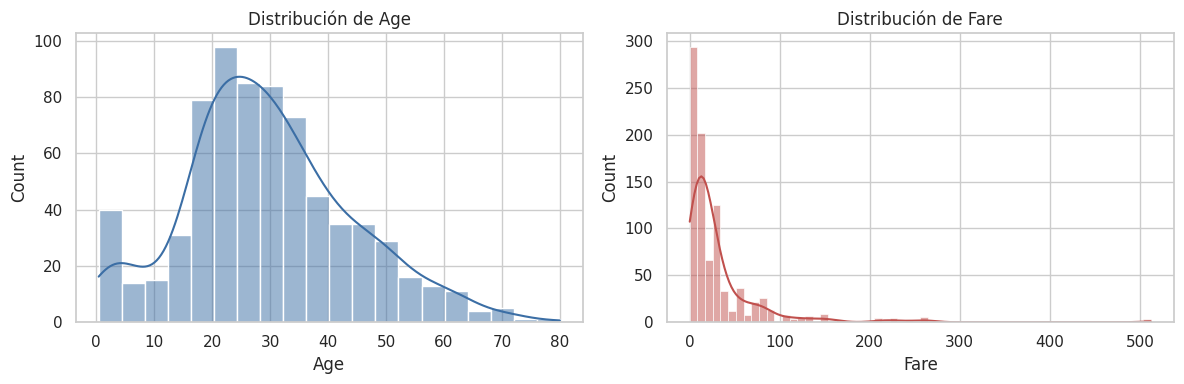

In [ ]:
# Distribuciones univariantes de variables numéricas clave
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(titanic["Age"], kde=True, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Distribución de Age")
sns.histplot(titanic["Fare"], kde=True, ax=axes[1], color="#c0504d")
axes[1].set_title("Distribución de Fare")
plt.tight_layout()
plt.show()


**Lectura orientativa:** `Age` muestra una distribución aproximadamente unimodal, concentrada entre 20 y 40 años, con una cola derecha moderada. `Fare` presenta una asimetría marcada hacia la derecha (la mayoría de los pasajeros pagó tarifas bajas, con un grupo minoritario de tarifas muy altas asociadas probablemente a primera clase), lo que se contrasta en la sección VI.


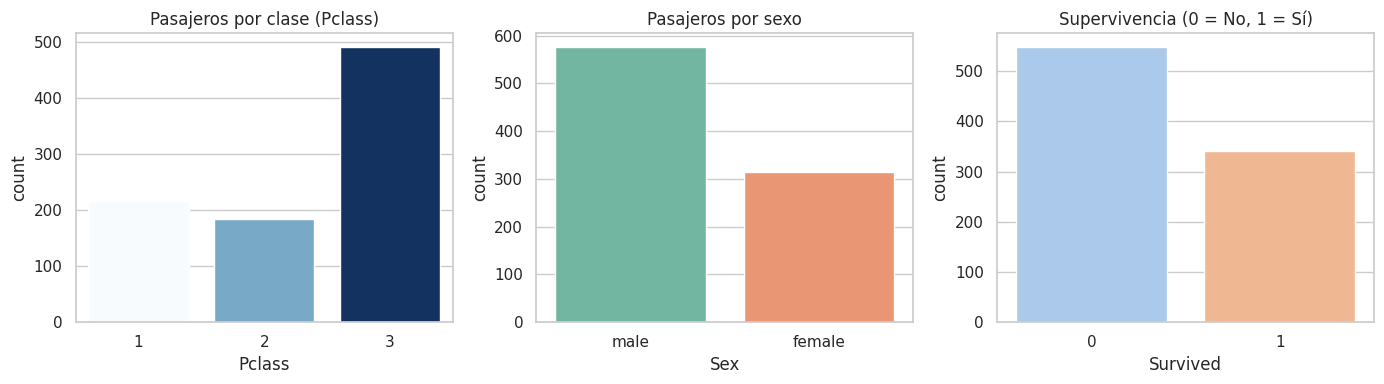

In [ ]:
# Distribución de variables categóricas relevantes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(data=titanic, x="Pclass", hue="Pclass", palette="Blues", legend=False, ax=axes[0])
axes[0].set_title("Pasajeros por clase (Pclass)")
sns.countplot(data=titanic, x="Sex", hue="Sex", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Pasajeros por sexo")
sns.countplot(data=titanic, x="Survived", hue="Survived", palette="pastel", legend=False, ax=axes[2])
axes[2].set_title("Supervivencia (0 = No, 1 = Sí)")
plt.tight_layout()
plt.show()


**Lectura orientativa:** la muestra está compuesta mayoritariamente por pasajeros de tercera clase y por hombres; la tasa de supervivencia global es minoritaria (más pasajeros no sobrevivieron que sobrevivieron). Estas proporciones son relevantes para interpretar con cautela las comparaciones de la sección VI, dado el desbalance de grupos.


# V. Decisiones y transformaciones iniciales

A partir de la revisión de calidad de la sección III, se adoptan las siguientes decisiones exploratorias. Cada una se documenta con su justificación y el resultado intermedio que produce, de modo que el proceso sea trazable.

**Decisión 1 - Imputación de `Age`:** Se decide imputar los 177 valores faltantes de `Age` (19,9%) usando la mediana de edad calculada por combinación de `Pclass` y `Sex`, en lugar de una mediana global, porque la edad promedio varía sensiblemente entre clases y sexos en este dataset, y una imputación más granular reduce el sesgo introducido. Se conserva la variable original en `Age` y se deja evidencia del resultado antes/después.

**Decisión 2 - Imputación de `Embarked`:** Solo 2 registros no tienen puerto de embarque. Se decide imputar con la moda (valor más frecuente), dado que el efecto de 2 registros sobre el análisis agregado es marginal.

**Decisión 3 - Tratamiento de `Deck`:** Dado que `Deck` tiene 77,2% de valores faltantes, no se imputa (una imputación con esa magnitud de faltantes introduciría más ruido que información). Se decide crear una variable binaria `Deck_conocido` (1 si se registró la cubierta, 0 si no) para preservar la señal de "dato disponible" sin fabricar valores, y se deja pendiente para fases posteriores decidir si `Deck` se descarta definitivamente o se recodifica.

**Decisión 4 - Variables derivadas de composición familiar:** Se crea `Family_size = SibSp + Parch + 1` (incluyendo al propio pasajero) y `Is_alone` (1 si `Family_size == 1`), para poder responder directamente la pregunta exploratoria 5 sobre el tamaño del grupo familiar.

**Decisión 5 - Grupo etario:** Se crea la variable categórica `Age_group` (Niño: 0–12, Joven: 13–25, Adulto: 26–59, Adulto mayor: 60+) a partir de `Age` ya imputada, para simplificar la lectura de la relación edad–supervivencia en la sección VI.


In [ ]:
# Decisión 1: imputación de Age por mediana de (Pclass, Sex)
print("Nulos en Age antes de imputar:", titanic["Age"].isna().sum())

mediana_age_grupo = titanic.groupby(["Pclass", "Sex"])["Age"].median()
print("\nMediana de Age por Pclass y Sex:")
print(mediana_age_grupo)

titanic["Age"] = titanic.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda serie: serie.fillna(serie.median())
)
print("\nNulos en Age después de imputar:", titanic["Age"].isna().sum())


Nulos en Age antes de imputar: 177

Mediana de Age por Pclass y Sex:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Nulos en Age después de imputar: 0


In [ ]:
# Decisión 2: imputación de Embarked por moda
print("Nulos en Embarked antes de imputar:", titanic["Embarked"].isna().sum())
moda_embarked = titanic["Embarked"].mode()[0]
print("Moda utilizada:", moda_embarked)
titanic["Embarked"] = titanic["Embarked"].fillna(moda_embarked)
titanic["Embark_Town"] = titanic["Embark_Town"].fillna(titanic["Embark_Town"].mode()[0])
print("Nulos en Embarked después de imputar:", titanic["Embarked"].isna().sum())


Nulos en Embarked antes de imputar: 2
Moda utilizada: S
Nulos en Embarked después de imputar: 0


In [ ]:
# Decisión 3: variable Deck_conocido (sin imputar Deck)
titanic["Deck_conocido"] = titanic["Deck"].notna().astype(int)
print(titanic["Deck_conocido"].value_counts())


Deck_conocido
0    688
1    203
Name: count, dtype: int64


In [ ]:
# Decisión 4: variables de composición familiar
titanic["Family_size"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["Is_alone"] = (titanic["Family_size"] == 1).astype(int)
titanic[["SibSp", "Parch", "Family_size", "Is_alone"]].head()


,SibSp,Parch,Family_size,Is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [ ]:
# Decisión 5: grupo etario derivado de Age ya imputada
bins = [0, 12, 25, 59, 100]
labels = ["Niño (0-12)", "Joven (13-25)", "Adulto (26-59)", "Adulto mayor (60+)"]
titanic["Age_group"] = pd.cut(titanic["Age"], bins=bins, labels=labels, right=True)
titanic["Age_group"].value_counts().sort_index()


Age_group
Niño (0-12)            69
Joven (13-25)         368
Adulto (26-59)        428
Adulto mayor (60+)     26
Name: count, dtype: int64

**Resultado intermedio de esta sección:** tras las transformaciones anteriores, el dataset de trabajo ya no presenta valores faltantes en `Age` ni en `Embarked`/`Embark_Town`; `Deck` se mantiene sin imputar pero acompañada de `Deck_conocido` como señal explícita; y se cuenta con tres variables derivadas (`Family_size`, `Is_alone`, `Age_group`) que permiten responder de forma más directa las preguntas exploratorias 2 y 5. Se verifica a continuación el estado final de nulos.


In [ ]:
# Verificación del estado de nulos tras las transformaciones
titanic.isna().sum().sort_values(ascending=False)


Deck             688
Survived           0
PassengerId        0
Sex                0
Age                0
SibSp              0
Pclass             0
Parch              0
Fare               0
Embarked           0
Embark_Town        0
Deck_conocido      0
Family_size        0
Is_alone           0
Age_group          0
dtype: int64

# VI. Resultados e interpretación inicial

Con el dataset transformado, se retoman explícitamente las cinco preguntas exploratorias planteadas en la sección II para explorar patrones asociados a la supervivencia.


Tasa de supervivencia por sexo:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


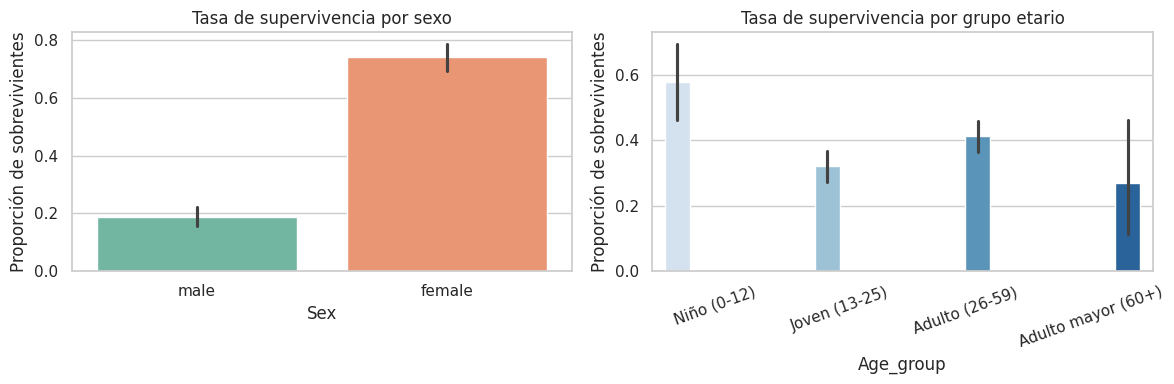

In [ ]:
# Pregunta 2: supervivencia según sexo y edad
tasa_por_sexo = titanic.groupby("Sex")["Survived"].mean().round(3)
print("Tasa de supervivencia por sexo:")
print(tasa_por_sexo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=titanic, x="Sex", y="Survived", hue="Sex", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Tasa de supervivencia por sexo")
axes[0].set_ylabel("Proporción de sobrevivientes")

sns.barplot(data=titanic, x="Age_group", y="Survived", hue="Age_group", palette="Blues",
            legend=False, ax=axes[1], order=labels)
axes[1].set_title("Tasa de supervivencia por grupo etario")
axes[1].set_ylabel("Proporción de sobrevivientes")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


**Interpretación (Pregunta 2):** la tasa de supervivencia es considerablemente más alta entre mujeres que entre hombres, consistente con el patrón histórico de prioridad de evacuación. Por grupo etario, los niños (0-12) muestran una tasa de supervivencia superior al resto de los grupos, mientras que adultos y adultos mayores presentan tasas más bajas y similares entre sí.


Tasa de supervivencia por clase:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


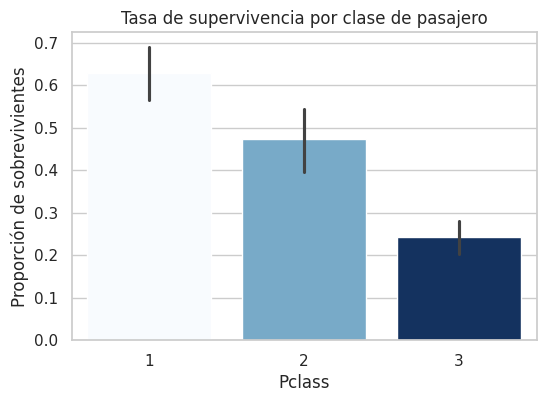

In [ ]:
# Pregunta 3: relación entre Pclass y supervivencia
tasa_por_clase = titanic.groupby("Pclass")["Survived"].mean().round(3)
print("Tasa de supervivencia por clase:")
print(tasa_por_clase)

plt.figure(figsize=(6, 4))
sns.barplot(data=titanic, x="Pclass", y="Survived", hue="Pclass", palette="Blues", legend=False)
plt.title("Tasa de supervivencia por clase de pasajero")
plt.ylabel("Proporción de sobrevivientes")
plt.show()


**Interpretación (Pregunta 3):** se observa una relación aparente clara entre clase de pasajero y supervivencia: primera clase presenta la tasa más alta y tercera clase la más baja, de forma monotónica. Esto es consistente con la hipótesis de que la clase se asocia con acceso preferente a botes salvavidas y ubicación en el barco, aunque esta fase no establece causalidad.


Tarifa promedio por clase y puerto de embarque:
Pclass  Embarked
1       C           104.72
        Q            90.00
        S            70.51
2       C            25.36
        Q            12.35
        S            20.33
3       C            11.21
        Q            11.18
        S            14.64
Name: Fare, dtype: float64


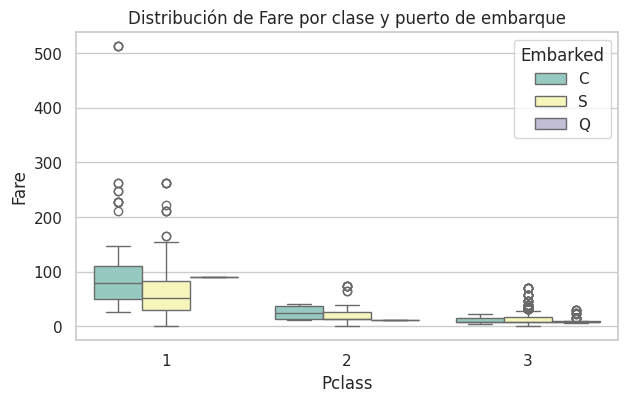

In [ ]:
# Pregunta 4: relación entre Fare, Pclass y puerto de embarque
resumen_fare = titanic.groupby(["Pclass", "Embarked"])["Fare"].mean().round(2)
print("Tarifa promedio por clase y puerto de embarque:")
print(resumen_fare)

plt.figure(figsize=(7, 4))
sns.boxplot(data=titanic, x="Pclass", y="Fare", hue="Embarked", palette="Set3")
plt.title("Distribución de Fare por clase y puerto de embarque")
plt.show()


**Interpretación (Pregunta 4):** la tarifa promedio decrece de primera a tercera clase, como es esperable, y dentro de una misma clase existen diferencias según el puerto de embarque (Cherbourg tiende a concentrar tarifas más altas en primera clase). Se observan también valores atípicos de `Fare` en primera clase, coherentes con boletos de alto costo.


Tasa de supervivencia por tamaño de grupo familiar:
Family_size
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64


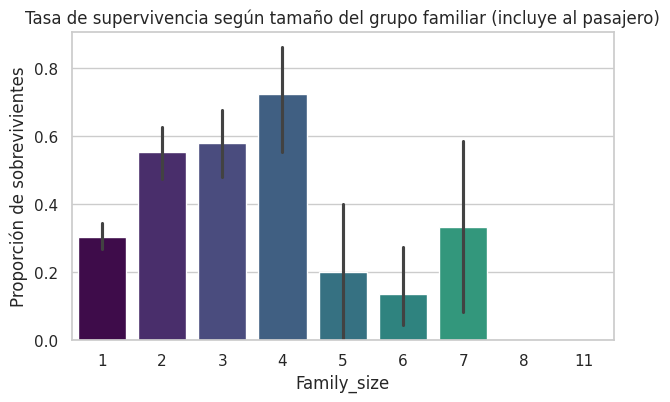

In [ ]:
# Pregunta 5: supervivencia según tamaño del grupo familiar
tasa_por_familia = titanic.groupby("Family_size")["Survived"].mean().round(3)
print("Tasa de supervivencia por tamaño de grupo familiar:")
print(tasa_por_familia)

plt.figure(figsize=(7, 4))
sns.barplot(data=titanic, x="Family_size", y="Survived", hue="Family_size", palette="viridis", legend=False)
plt.title("Tasa de supervivencia según tamaño del grupo familiar (incluye al pasajero)")
plt.ylabel("Proporción de sobrevivientes")
plt.show()


**Interpretación (Pregunta 5):** los pasajeros que viajaban solos (`Family_size = 1`) y aquellos con grupos muy numerosos (5 o más integrantes) muestran tasas de supervivencia más bajas, mientras que los grupos familiares pequeños a medianos (2 a 4 integrantes) presentan las tasas más altas. Esto sugiere un patrón no lineal entre tamaño de grupo y supervivencia, a explorar con mayor detalle en fases posteriores.


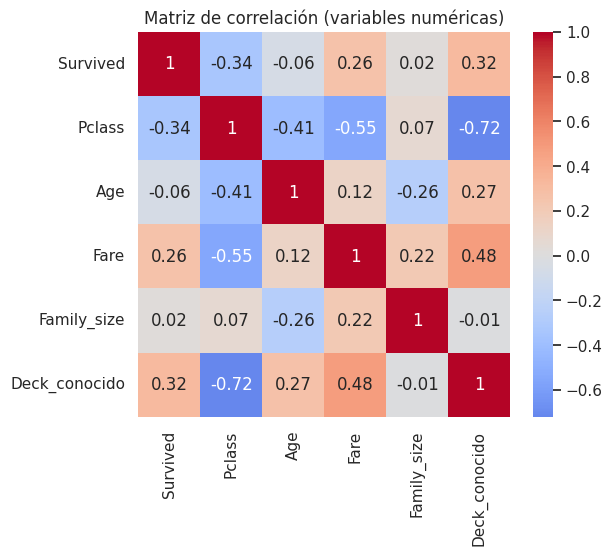

In [ ]:
# Correlación entre variables numéricas relevantes
variables_numericas = ["Survived", "Pclass", "Age", "Fare", "Family_size", "Deck_conocido"]
matriz_corr = titanic[variables_numericas].corr().round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables numéricas)")
plt.show()


**Interpretación general:** la correlación más fuerte con `Survived` corresponde a `Pclass` (negativa: a mayor número de clase —peor categoría—, menor supervivencia) y a `Deck_conocido` (positiva: tener cubierta registrada se asocia a mayor supervivencia, probablemente porque esa información se registró de forma más completa para pasajeros de clases altas). Estas relaciones son consistentes con lo observado en los gráficos anteriores y responden de manera directa a las cinco preguntas exploratorias planteadas en la sección II.


# VII. Supuestos y limitaciones

**Supuestos considerados durante el análisis:**
- Se asume que la versión del dataset Titanic distribuida por `seaborn` es equivalente, en su contenido sustantivo, a la versión clásica utilizada en actividades formativas previas del curso, dado que no se encontró un archivo previo del equipo en la carpeta de trabajo.
- Se asume que las 107 filas con atributos idénticos corresponden a pasajeros distintos con características coincidentes, y no a errores de carga o duplicación real de registros (el dataset no incluye identificadores como nombre o número de ticket que permitan verificarlo de forma directa).
- Se asume que la imputación de `Age` por mediana de (`Pclass`, `Sex`) es una aproximación razonable para esta fase exploratoria, sin pretender ser la estrategia definitiva de tratamiento de nulos del proyecto.

**Limitaciones detectadas:**
- `Deck` mantiene un 77,2% de valores faltantes no imputados; cualquier análisis que la involucre debe considerarse preliminar y de baja confiabilidad.
- El análisis presentado es descriptivo y bivariado; no se han evaluado interacciones múltiples entre variables ni significancia estadística de las diferencias observadas.
- La muestra está desbalanceada en `Sex` y `Pclass`, lo que puede amplificar visualmente algunas diferencias de tasas de supervivencia.

**Aspectos pendientes para fases siguientes:**
- Definir el tratamiento final de `Deck` (descarte, recodificación agregada u otra estrategia).
- Evaluar pruebas de significancia estadística sobre las diferencias de supervivencia identificadas.
- Avanzar hacia la integración de tablas derivadas y, eventualmente, el modelamiento predictivo, conforme lo indiquen las fases posteriores del proyecto.


# VIII. Cierre del avance

En este primer avance se cargó y revisó el dataset Titanic, se evaluó su calidad (identificando nulos en `Age`, `Embarked` y `Deck`, y filas con atributos idénticos), se realizó una exploración preliminar de sus variables principales, y se documentaron cinco decisiones de transformación (imputación de `Age` y `Embarked`, tratamiento de `Deck`, y creación de las variables derivadas `Family_size`, `Is_alone` y `Age_group`).

**Principales hallazgos de esta fase:** la supervivencia se asocia de forma aparente con el sexo (mayor en mujeres), la clase de pasajero (mayor en primera clase, de forma monotónica), el grupo etario (mayor en niños) y el tamaño del grupo familiar (mayor en grupos pequeños a medianos frente a viajar solo o en grupos muy numerosos). La tarifa (`Fare`) se relaciona con la clase y, en menor medida, con el puerto de embarque.

**Proyección para las siguientes fases:** se espera profundizar el análisis bivariado con pruebas estadísticas formales, resolver el tratamiento definitivo de `Deck`, y avanzar hacia la integración de tablas derivadas y el modelamiento predictivo de la supervivencia, construyendo sobre la base reproducible establecida en este avance.
